<a href="https://colab.research.google.com/github/LizaMilovanova/Labs/blob/main/%D0%9B%D0%A0_2_1_%D0%9C%D1%96%D0%BB%D0%BE%D0%B2%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група
Мілованова Єлизавета
---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [64]:
import pandas as pd
import requests

In [65]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)  # зчитати всі таблиці
df = tables[2]
df.head()

/tmp/ipykernel_2320/390661927.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)  # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [66]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


In [68]:
df.dtypes

,0
Country/Territory,object
IMF (2026)[1],object
World Bank (2025)[6],object
United Nations (2024)[7],object


In [69]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [70]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [74]:
df.head()
#не видаляю стовпці бо суперечить виконанню подальших завдань

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [75]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [78]:
# Convert columns to float type
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [79]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [80]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [81]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [82]:
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(df.iloc[:, 1:].mean())

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [83]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
212,Saint Martin,661460.289474,626049.693548,522491.207547
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,661460.289474,626049.693548,456.000000
215,Cook Islands,661460.289474,626049.693548,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,661460.289474,626049.693548,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
#df.drop_duplicates(inplace=True)

7.	Вивести описову статистику датасету describe()

In [86]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05
std,2.666759e+06,2.520399e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.895900e+04,1.992800e+04,8.840000e+03
50%,1.020420e+05,9.977400e+04,4.276500e+04
75%,6.614603e+05,6.260497e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [87]:
# Count difference between IMF_Forecast and WB_Estimate for each country
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

# Find which country has the largest difference between IMF and WB
max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [88]:
# Calculate correlation between IMF and WB and UN
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9986385217562858
Correlation between IMF and UN: 0.9973427521857388
Correlation between WB and UN: 0.997011380809274


In [89]:
# Find highest correlation
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [91]:
# Find mean of IMF, WB and UN
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(661460.2894736842)

In [92]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(626049.6935483871)

In [93]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(522491.2075471698)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [94]:
# Find standard deviation for each row
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [95]:
# Find max and min GDP for each year
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

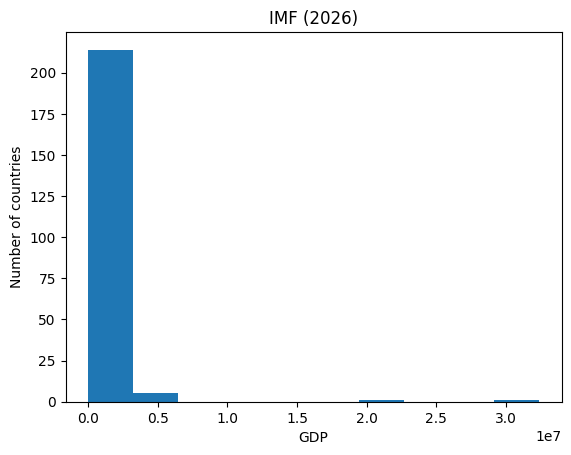

In [96]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [97]:
# Calculate share of world GDP for each country for each year
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.221530,0.222394,0.253727
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.142641,0.140926,0.162325
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.037302,0.036506,0.040356
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.029957,0.032056,0.034868
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.029174,0.028929,0.031921
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.028411,0.028593,0.034227
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.024600,0.024331,0.027370
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.018731,0.018442,0.020618
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.018172,0.018512,0.018822
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.018032,0.016479,0.018930


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [98]:
# Find top 10 countries with the most significant change in share of world GDP between IMF and UN
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,3.238392e+07,3.076970e+07,29298000.0,1.614220e+06,1.465578e+07,0.221530,0.222394,2.537270e-01,0.032197
2,China[n 1],2.085159e+07,1.949804e+07,18743802.0,1.353554e+06,9.213488e+06,0.142641,0.140926,1.623254e-01,0.019685
6,India,4.153191e+06,3.956067e+06,3952244.0,1.971240e+05,1.913990e+06,0.028411,0.028593,3.422729e-02,0.005816
4,Japan,4.379253e+06,4.435163e+06,4026211.0,5.591000e+04,2.119895e+06,0.029957,0.032056,3.486786e-02,0.004910
220,Montserrat,6.614603e+05,6.260497e+05,81.0,3.541060e+04,3.620030e+05,0.004525,0.004525,7.014775e-07,0.004524
215,Cook Islands,6.614603e+05,6.260497e+05,414.0,3.541060e+04,3.619017e+05,0.004525,0.004525,3.585330e-06,0.004521
214,Anguilla,6.614603e+05,6.260497e+05,456.0,3.541060e+04,3.618889e+05,0.004525,0.004525,3.949059e-06,0.004521
197,Sint Maarten,6.614603e+05,1.888000e+03,1670.0,6.595723e+05,3.803229e+05,0.004525,0.000014,1.446256e-05,0.004510
201,Turks and Caicos Islands,6.614603e+05,6.260497e+05,1757.0,3.541060e+04,3.614933e+05,0.004525,0.004525,1.521600e-05,0.004510
199,British Virgin Islands,6.614603e+05,6.260497e+05,1830.0,3.541060e+04,3.614711e+05,0.004525,0.004525,1.584820e-05,0.004509
